# SHAP Generation and Explanations

This notebook demonstrates how to generate SHAP explanations for compound selectivity models in this repository.

It includes:
- Optional end-to-end training (dataset -> features -> split -> model)
- SHAP generation from an existing split/model pair
- Atom-level SHAP visualizations on molecules
- SHAP explanations for custom SMILES strings

## Workflow Overview

1. Configure paths and model settings.
2. Either train a new model or reuse existing split/model artifacts.
3. Compute SHAP values for a selected split.
4. Render atom-level SHAP heatmaps for selected compounds.
5. Explain one custom SMILES and render its SHAP map.

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_workspace_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists() and (parent / "src").exists():
            return parent
    raise FileNotFoundError("Could not locate workspace root with pyproject.toml and src/")

workspace_root = find_workspace_root(Path.cwd())
src_path = workspace_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Workspace root: {workspace_root}")
print(f"Using src path:   {src_path}")

Workspace root: C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Using src path:   C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src


In [ ]:
from chemagent.datasets.dataset_tools import (
    find_datasets,
    load_dataset,
    compute_features,
    split_dataset,
)
from chemagent.ml.training_tools import train_model, check_training

from chemagent.explainability.shap_explainer import (
    explain_with_shap,
    explain_smiles_with_shap,
    plot_shap_mol,
)

print("SHAP tools imported successfully.")

SHAP tools imported successfully.


In [6]:
# -------------------- User Configuration --------------------
USE_EXISTING_ARTIFACTS = True

# If training a new model, choose a dataset CSV in data/datasets
dataset_csv = "data/datasets/chembl_activity_data_O00329_P42336.csv"

# Featurization settings (must match SHAP settings later)
n_bits = 2048
radius = 2

# Split/train settings
algorithm = "RFC"
task = "classification"
train_size, val_size, test_size = 0.7, 0.0, 0.3
seed = 42

# SHAP settings
analysis_split = "test"
correct_only = True
plot_sample_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Indices of samples to plot (must be in the chosen split)

# Custom SMILES (if None, auto-picks first available SMILES from split SHAP output)
custom_smiles = None

# Optional fallback artifact paths (used if auto-discovery fails)
manual_split_file_path = None
manual_model_path = None

output_dir = workspace_root / "notebooks" / "debug_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


In [7]:
def latest_file(pattern: str) -> str | None:
    matches = list(workspace_root.glob(pattern))
    if not matches:
        return None
    return str(max(matches, key=lambda p: p.stat().st_mtime))

def latest_model_file(selected_algorithm: str) -> str | None:
    algo = (selected_algorithm or "").strip()

    # Prefer the selected algorithm first (new nested and older flat layouts).
    preferred_patterns = []
    if algo:
        preferred_patterns.append(f"data/logs/session_*/models/{algo}/**/*.pkl")
        preferred_patterns.append(f"data/logs/session_*/models/{algo}/*.pkl")
        preferred_patterns.append(f"data/logs/session_*/models/*_{algo}.pkl")

    # Backward-compatible generic fallbacks.
    fallback_patterns = [
        "data/logs/session_*/models/**/*.pkl",
        "data/logs/session_*/models/*.pkl",
    ]

    seen = set()
    preferred_matches = []
    for pattern in preferred_patterns:
        for path in workspace_root.glob(pattern):
            resolved = str(path.resolve())
            if resolved not in seen:
                seen.add(resolved)
                preferred_matches.append(path)

    if preferred_matches:
        return str(max(preferred_matches, key=lambda p: p.stat().st_mtime))

    fallback_matches = []
    for pattern in fallback_patterns:
        for path in workspace_root.glob(pattern):
            resolved = str(path.resolve())
            if resolved not in seen:
                seen.add(resolved)
                fallback_matches.append(path)

    if not fallback_matches:
        return None

    return str(max(fallback_matches, key=lambda p: p.stat().st_mtime))

if USE_EXISTING_ARTIFACTS:
    split_file_path = latest_file("data/logs/session_*/splits/*.pkl") or manual_split_file_path
    model_path = latest_model_file(algorithm) or manual_model_path

    if not split_file_path or not model_path:
        raise FileNotFoundError(
            "Could not auto-discover split/model artifacts. "
            "Set USE_EXISTING_ARTIFACTS=False to train, or set manual_* paths."
        )

    print("Using existing artifacts:")
    print("algorithm       =", algorithm)
    print("split_file_path =", split_file_path)
    print("model_path      =", model_path)
else:
    available = find_datasets()
    print("Available datasets:")
    print(available)

    load_info = load_dataset(file_path=dataset_csv)
    dataset_id = load_info["dataset_id"]
    print("Loaded dataset_id:", dataset_id)

    feat_info = compute_features(dataset_id=dataset_id, method="ECFP", n_bits=n_bits, radius=radius)
    print("Feature summary:", feat_info)

    split_info = split_dataset(
        dataset_id=dataset_id,
        split_type="random",
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
        seed=seed,
        stratified=True,
    )
    split_file_path = split_info["saved_to"]
    print("Split file:", split_file_path)

    job = train_model(
        split_file_path=split_file_path,
        algorithm=algorithm,
        task=task,
        opt_metric="balanced_accuracy",
        random_seed=seed,
    )
    print("Training job submitted:", job)

    while True:
        status = check_training(job["job_id"], model_save_path=job["model_save_path"])
        print(status["status"], "elapsed:", status.get("elapsed_seconds", "n/a"))
        if status["status"] in {"completed", "failed"}:
            break
        time.sleep(30)

    if status["status"] != "completed":
        raise RuntimeError(f"Training failed: {status}")

    model_path = status.get("model_path") or status.get("result", {}).get("model_path") or job["model_save_path"]
    print("Model path:", model_path)

Using existing artifacts:
algorithm       = RFC
split_file_path = C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260410_105552_424135\splits\chembl_activity_data_O00329_P48736_scaffold.pkl
model_path      = C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260410_105552_424135\models\RFC\chembl_activity_data_O00329_P48736_scaffold_RFC.pkl


In [8]:
split_shap_path = output_dir / "shap_from_split.pkl"

shap_info = explain_with_shap(
    model_path=model_path,
    split_file_path=split_file_path,
    split=analysis_split,
    n_bits=n_bits,
    correct_only=correct_only,
    save_path=str(split_shap_path),
)

shap_info

{'shap_values_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_split.pkl',
 'n_samples': 225,
 'n_samples_total': 256,
 'n_correct': 225,
 'correct_only': True,
 'n_features': 2048,
 'expected_value': 0.6611205789530964,
 'expected_values_by_class': [0.7559010773751227,
  0.20712536728697362,
  0.03697355533790399],
 'expected_values_selected': [0.20712536728697362,
  0.20712536728697362,
  0.20712536728697362,
  0.20712536728697362,
  0.20712536728697362,
  0.20712536728697362,
  0.20712536728697362,
  0.20712536728697362,
  0.03697355533790399,
  0.20712536728697362,
  0.7559010773751227,
  0.20712536728697362,
  0.7559010773751227,
  0.7559010773751227,
  0.7559010773751227,
  0.7559010773751227,
  0.20712536728697362,
  0.7559010773751227,
  0.7559010773751227,
  0.7559010773751227,
  0.7559010773751227,
  0.7559010773751227,
  0.7559010773751227,
  0.20712536728697362,
  0.

In [9]:
shap_data = joblib.load(shap_info["shap_values_path"])
n_show = min(10, shap_data["shap_values"].shape[0])

if "smiles" in shap_data:
    smiles_preview = shap_data["smiles"][:n_show]
else:
    smiles_preview = np.array(["<no_smiles>"] * n_show)

if "labels" in shap_data:
    labels_preview = shap_data["labels"][:n_show]
else:
    labels_preview = np.array(["?"] * n_show)

preview = pd.DataFrame(
    {
        "smiles": smiles_preview,
        "label": labels_preview,
        "mean_abs_shap": np.abs(shap_data["shap_values"][:n_show]).mean(axis=1),
        "top_bit": np.abs(shap_data["shap_values"][:n_show]).argmax(axis=1),
        #"expected_value": shap_data.get("expected_value", [np.nan] * n_show)[:n_show],
    }
)

preview

,smiles,label,mean_abs_shap,top_bit
0,Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N...,1,0.000447,1026
1,CC(Nc1ncnc(N)c1C#N)c1cc2ncc(Cl)n2nc1-c1cnn(C)c1,1,0.000464,1367
2,CC(Nc1ncnc(N)c1C#N)c1cc2ncc(Cl)n2cc1-c1ccccc1,1,0.000455,1367
3,CC(Nc1ncnc(N)c1C#N)c1nc2cccc(Cl)c2c(=O)n1Cc1cc...,1,0.000455,690
4,CC(=O)N1CCN(C(=O)c2cccc(-c3ncnc4ccc(-c5cnc6ccc...,1,0.000420,618
5,CC(Nc1nc(N)nc(N)c1C#N)c1nc2cccc(Cl)c2c(=O)n1CC...,1,0.000443,690
6,CC(Nc1ncnc(N)c1C#N)c1nc2ccc(F)cc2c(C(=O)N2CCNC...,1,0.000464,1367
7,COc1ncc(-c2cc(OC3CN(C(=O)C4CC4)C3)cc3c2CNC3=O)...,1,0.000426,53
8,CC(C1CC1)N1Cc2cc(-c3ccn4nc(N)c(C(=O)NC5CC5)c4n...,2,0.000491,679
9,CC(Nc1nc(N)nc(N)c1C#N)c1nc2cccc(Cl)c2c(=O)n1Cc...,1,0.000449,690


In [10]:
preview.smiles.values[6]

'CC(Nc1ncnc(N)c1C#N)c1nc2ccc(F)cc2c(C(=O)N2CCNCC2)c1-c1ccccn1'

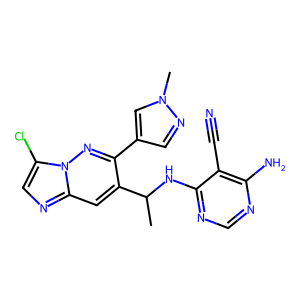

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
Draw.MolToImage(Chem.MolFromSmiles(preview.smiles.values[1]))+

In [11]:
shap_data.get("expected_value")

0.6611205789530964

In [ ]:
plot_outputs = plot_shap_mol(
    shap_values_path=shap_info["shap_values_path"],
    sample_indices=plot_sample_indices,
    mol_size=[700, 700],
    cmap="coolwarm",
)

plot_summary = plot_outputs[0]
plot_summary

In [ ]:
for img_path in plot_summary["generated"]:
    print(img_path)
    display(Image(filename=img_path))

In [9]:
if custom_smiles is None:
    if "smiles" in shap_data and len(shap_data["smiles"]) > 0:
        custom_smiles = str(shap_data["smiles"][0])
    else:
        raise ValueError("No SMILES available to auto-select. Set custom_smiles manually.")

print("SMILES for direct explanation:", custom_smiles)

smiles_shap_path = output_dir / "shap_from_smiles.pkl"
smiles_info = explain_smiles_with_shap(
    model_path=model_path,
    smiles=[custom_smiles],
    method="ECFP",
    split_file_path=split_file_path,
    n_bits=n_bits,
    radius=radius,
    save_path=str(smiles_shap_path),
)

smiles_info

SMILES for direct explanation: Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N5CCOCC5)c4s3)CC1CC2


{'shap_values_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_smiles.pkl',
 'n_samples': 1,
 'n_features': 2048,
 'expected_value': 0.7514669652855543,
 'prediction': 1,
 'mean_abs_shap': 0.0004130274882188449,
 'shap_sum': 0.596400709219608,
 'method': 'ECFP',
 'has_smiles': True,
 'note': 'Labels in output file are model predictions, not ground truth.',
 'next_step': "Call plot_shap_mol('C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\notebooks\\debug_outputs\\shap_from_smiles.pkl') to render atom-level SHAP heatmaps. Labels shown reflect the model's predicted class."}

In [10]:
smiles_plot_outputs = plot_shap_mol(
    shap_values_path=smiles_info["shap_values_path"],
    sample_indices=[0],
    mol_size=[700, 500],
    cmap="coolwarm",
)

smiles_plot_summary = smiles_plot_outputs[0]
smiles_plot_summary

{'generated': ['C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_0_label1.png'],
 'molecules': {'0': {'path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260330_170400_c68b54\\plots\\shap_mol_0_label1.png',
   'smiles': 'Cc1nnc2n1C1CCN(Cc3cc4nc(-c5cccc6[nH]ccc56)nc(N5CCOCC5)c4s3)CC1CC2',
   'label': '1',
   'cid': '0'}}}

C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260330_170400_c68b54\plots\shap_mol_0_label1.png


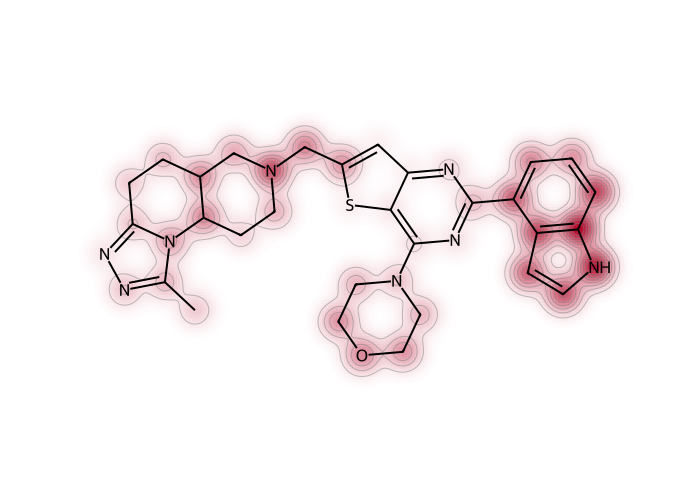

In [11]:
for img_path in smiles_plot_summary["generated"]:
    print(img_path)
    display(Image(filename=img_path))

## Interpretation Notes

- Large absolute SHAP values indicate fingerprint bits with strong influence on predictions.
- The SHAP molecule plots map bit-level contributions to atom-level heatmaps.
- For valid mapping, keep featurization consistent with training (`method`, `n_bits`, `radius`).
- For `explain_smiles_with_shap`, labels in output are model predictions, not ground truth.

In [5]:
path = 'C:/Users/janela/OneDrive - uni-bonn.de/Code/AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability/data/logs/session_tiago_20260416_103710_55bcdb'
model_path = Path(path) / "models" / "chembl_activity_RFC.pkl"
model = joblib.load(model_path)
dataset = pd.read_csv(Path(path) / "datasets" / "chembl_activity_data_P14416_binary.csv")
data_split_path = Path(path) / "splits" / "chembl_activity_data_P14416_binary_random.pkl"
data_split = joblib.load(data_split_path)


In [6]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
from chemagent.featurization.fingerprints import ECFP
ecfp_fp = np.array([ECFP(['CCCN(CCCCN1C(=O)CC(C)(C)CC1=O)C1CCc2ccc3[nH]c(C#N)cc3c2C1'])][0])
ecfp_fp

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 2048))

In [8]:
cpd_prediction = model.predict(ecfp_fp)
cpd_prediction

array([1])

In [9]:
from shap import TreeExplainer
explainer = TreeExplainer(model, feature_perturbation="interventional", data=data_split["train_features"])

In [10]:
cpd_explanation = explainer.shap_values(ecfp_fp)
cpd_explanation

array([[[ 0.00000000e+00,  0.00000000e+00],
        [-9.45056536e-04,  9.45056631e-04],
        [-1.46198526e-04,  1.46198525e-04],
        ...,
        [ 5.20041064e-04, -5.20041058e-04],
        [ 8.69746941e-05, -8.69746960e-05],
        [ 3.44444453e-05, -3.44444433e-05]]], shape=(1, 2048, 2))

In [11]:
from chemagent.explainability.shap_explainer import SHAPExplainer

In [12]:
shap_ex = SHAPExplainer(model=model, background=data_split["train_features"], max_background=1000)
shap_ex

In [13]:
explaination = shap_ex.explain(ecfp_fp)

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was -65011.700393, while the model output was 0.380000. If this difference is acceptable you can set check_additivity=False to disable this check.

In [4]:
explaination = explain_smiles_with_shap(model_path, ['CCCN(CCCCN1C(=O)CC(C)(C)CC1=O)C1CCc2ccc3[nH]c(C#N)cc3c2C1'])
explaination

{'shap_values_path': 'C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260416_103710_55bcdb\\results\\chembl_activity_RFC_smiles_shap.pkl',
 'n_samples': 1,
 'n_features': 2048,
 'expected_value': 0.5002977922300187,
 'expected_values_by_class': [0.4997022077699812, 0.5002977922300187],
 'expected_values_selected': [0.5002977922300187],
 'expected_value_classes': [0, 1],
 'expected_value_mode': 'class_1_or_single',
 'prediction': 1,
 'mean_abs_shap': 7.789469019477012,
 'shap_sum': 15393.1241525544,
 'method': 'ECFP',
 'has_smiles': True,
 'note': 'Labels in output file are model predictions, not ground truth.',
 'next_step': "Call plot_shap_mol('C:\\Users\\janela\\OneDrive - uni-bonn.de\\Code\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\data\\logs\\session_tiago_20260416_103710_55bcdb\\results\\chembl_activity_RFC_smiles_shap.pkl') to render atom-level SHAP heatmaps. Label